In [93]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt


In [90]:
tau = 0.9
prob_state0 = 0.3
theta = 0.3

def calc_externality(x):
    alpha, beta = x[0], x[1]
    pr1 = theta - alpha * theta + beta - theta * beta
    #return tau * prob_state0 + tau * (1 - 2 * prob_state0) * pr1
    return tau * (1 - 2 * prob_state0) * pr1


def calc_value(x):
    alpha, beta = x[0], x[1]
    return (alpha - beta) * theta + beta - np.maximum(theta, 1-theta)

def calc_neg_value(x):
    return -calc_value(x)

def calc_objective(x):
    return calc_externality(x)-calc_value(x)


constraint = {
    'type': 'ineq',  # Inequality constraint
    'fun': lambda x: x[0] + x[1] - 1  # g(x) = x[0] + x[1] - 1
}

constraints = [constraint]
bounds = [(0.5, 0.5), (0, 1,)]
#bounds = [(0.5, 0.5), (0, 1,)]
x0 = np.random.uniform(size=2)

res = np.round(np.array(minimize(calc_externality, x0=x0, constraints=constraints, bounds=bounds).x), 2)
print("alpha:", res[0], "beta:", res[1])

alpha: 0.5 beta: 0.5


In [91]:
res = np.round(np.array(minimize(calc_neg_value, x0=x0, constraints=constraints, bounds=bounds).x), 2)
print("alpha:", res[0], "beta:", res[1])

alpha: 0.5 beta: 1.0


In [86]:
calc_externality((0.5, 0.5))

0.04000000000000001

(-0.05, 1.05)

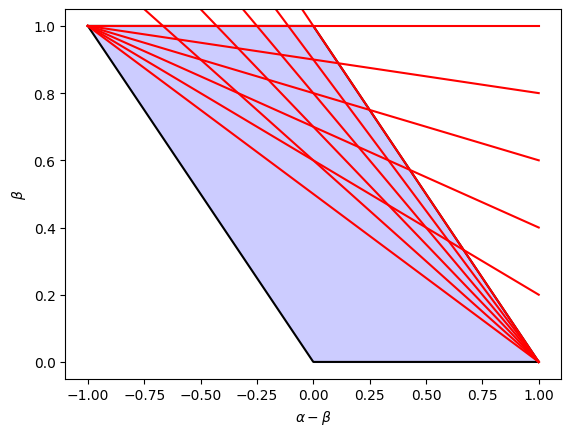

In [126]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

xs = np.linspace(-1, 1, 1000)

boundary_bottom = np.zeros(len(xs))
boundary_bottom[xs <= 0] = -xs[xs <= 0]

boundary_top = np.ones(len(xs))
boundary_top[xs >= 0] = -xs[xs >= 0] + 1

ax.plot(xs, boundary_bottom, color="k")
ax.plot(xs, boundary_top, color="k")
ax.fill_between(xs, boundary_top, boundary_bottom, color="b", alpha=0.2)

for type in np.linspace(0, 1, 11):

    beta_indiff = np.zeros(len(xs))
    #type = 0.5
    value = 0
    beta_indiff = value - type * xs + np.maximum(type, 1-type)


    ax.set_ylabel(r"$\beta$")
    ax.set_xlabel(r"$\alpha - \beta$")
    ax.plot(xs, beta_indiff, color="red")

ax.set_ylim([-0.05, 1.05])

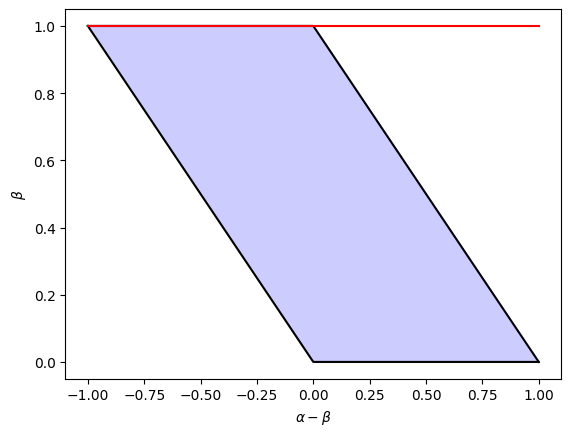

In [182]:
fig, ax = plt.subplots()

xs = np.linspace(-1, 1, 1000)

boundary_bottom = np.zeros(len(xs))
boundary_bottom[xs <= 0] = -xs[xs <= 0]

boundary_top = np.ones(len(xs))
boundary_top[xs >= 0] = -xs[xs >= 0] + 1

ax.plot(xs, boundary_bottom, color="k")
ax.plot(xs, boundary_top, color="k")
ax.fill_between(xs, boundary_top, boundary_bottom, color="b", alpha=0.2)



beta_indiff = np.zeros(len(xs))
type = 0
externality = 0
tau = 1
prob_state0 = 0

beta_indiff = xs * type / (1 - 2 * type) #+ (externality - tau * prob_state0 - type * tau * (1 - 2 * prob_state0)) / (tau * (1 - 2 * prob_state0) * (1 - 2 * type))
state = 0
ex = 0
beta_indiff = xs * type / (1 - 2 * type) - (1 - state) / ((2*state - 1) * (1 - 2*type)) - type/(1-2*type) + ex / (tau * (2 * state - 1) * 1 - 2 *type)


ax.set_ylabel(r"$\beta$")
ax.set_xlabel(r"$\alpha - \beta$")
ax.plot(xs, beta_indiff, color="red")

# ax.set_ylim([-0.05, 1.05])


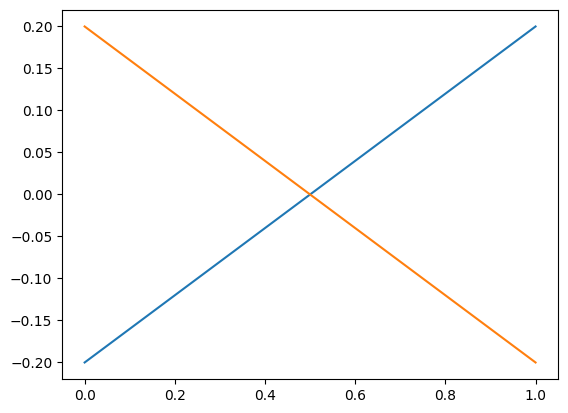

In [189]:
delta_beta = 0.2
types = np.linspace(0, 1, 1000)
state = 0
tau = 1
delta_ex = lambda state: delta_beta * (1 - 2 * types) * (2 * state - 1) * tau

plt.plot(types, delta_ex(0))
plt.plot(types, delta_ex(1))

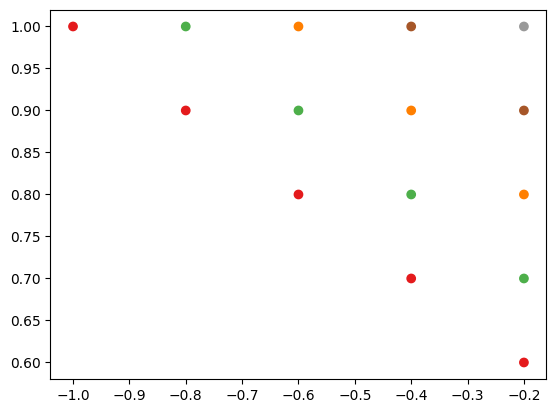

In [239]:
xs = []
ys = []
vs = []

theta = 0.5
for x in np.linspace(-1, 1, 11):
    for y in np.linspace(0, 1, 11):
        if x >= 1 - 2*y:
            if x < 0:
                v = x * theta + y - theta
                vs.append(v)
                xs.append(x)
                ys.append(y)

plt.scatter(xs, ys, c=vs, cmap="Set1")

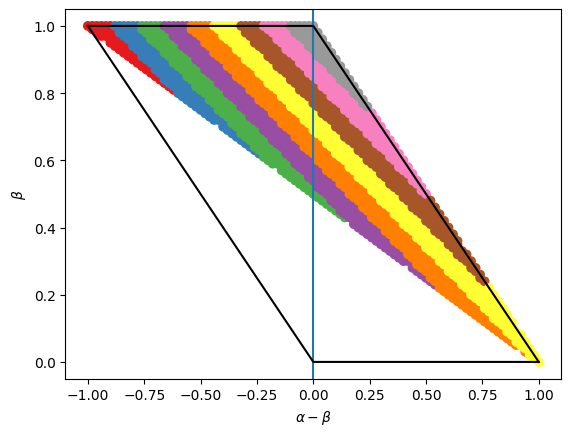

In [279]:
fig, ax = plt.subplots()

xs = []
ys = []
vs = []

N = 101
cmap = "Set1"

theta = 0.7
for x in np.linspace(-1, 1, N):
    for y in np.linspace(0, 1, N):
        if x >= 1 - 2 * y:
            if x + y <= 1:
                v = x * theta + y - theta
                vs.append(v)
                xs.append(x)
                ys.append(y)

ax.scatter(xs, ys, c=vs, cmap=cmap)
ax.set_xlabel(r"$\alpha - \beta$")
ax.set_ylabel(r"$\beta$")
ax.axvline(x=0)

xs = np.linspace(-1, 1, 1000)
boundary_top = np.ones(len(xs))
boundary_top[xs >= 0] = -xs[xs >= 0] + 1

ax.plot(xs, boundary_bottom, color="k")
ax.plot(xs, boundary_top, color="k")



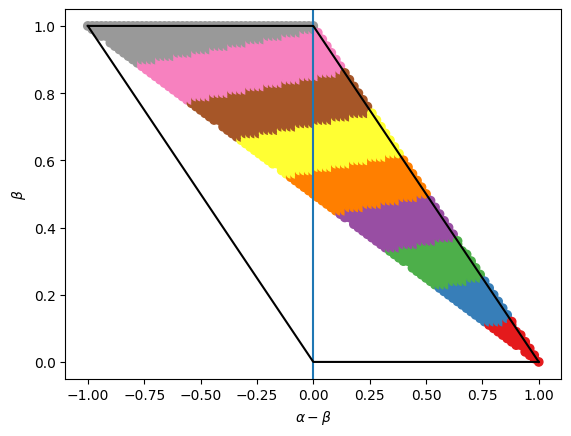

In [ ]:
fig, ax = plt.subplots()

xs = []
ys = []
vs = []

N = 101
cmap = "Set1"

prob_state0 = 0
tau = 0.9

theta = 0.1
for x in np.linspace(-1, 1, N):
    for y in np.linspace(0, 1, N):
        if x >= 1 - 2 * y:
            if x + y <= 1:
                beta = y
                alpha = x + beta
                pr1 = theta - alpha * theta + beta - theta * beta
                ex = tau * (1 - 2 * prob_state0) * pr1
                vs.append(ex)
                xs.append(x)
                ys.append(y)

ax.scatter(xs, ys, c=vs, cmap=cmap)
ax.set_xlabel(r"$\alpha - \beta$")
ax.set_ylabel(r"$\beta$")
ax.axvline(x=0)

xs = np.linspace(-1, 1, 1000)
boundary_top = np.ones(len(xs))
boundary_top[xs >= 0] = -xs[xs >= 0] + 1

ax.plot(xs, boundary_bottom, color="k")
ax.plot(xs, boundary_top, color="k")



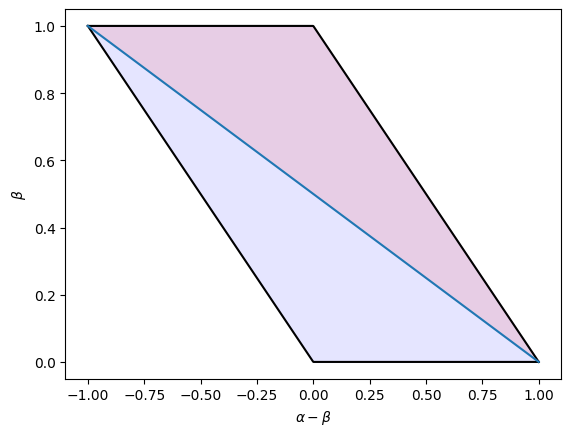

In [289]:
fig, ax = plt.subplots()

xs = np.linspace(-1, 1, 1000)

boundary_bottom = np.zeros(len(xs))
boundary_bottom[xs <= 0] = -xs[xs <= 0]

boundary_top = np.ones(len(xs))
boundary_top[xs >= 0] = -xs[xs >= 0] + 1

ax.plot(xs, boundary_bottom, color="k")
ax.plot(xs, boundary_top, color="k")
ax.fill_between(xs, boundary_top, boundary_bottom, color="b", alpha=0.1)

ax.set_xlabel(r"$\alpha - \beta$")
ax.set_ylabel(r"$\beta$")

boundary_bottom_actual = 0.5 * (1 - xs)
ax.plot(xs, boundary_bottom_actual)


ax.fill_between(xs, boundary_top, boundary_bottom_actual, color="r", alpha=0.1)


Text(0, 0.5, '$\\beta$')

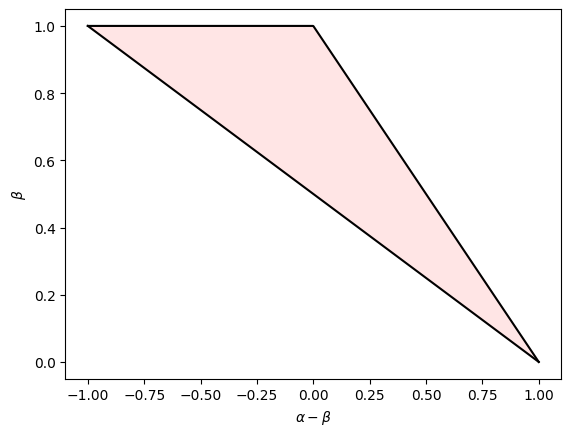

In [293]:
fig, ax = plt.subplots()

xs = np.linspace(-1, 1, 1000)


boundary_top = np.ones(len(xs))
boundary_top[xs >= 0] = -xs[xs >= 0] + 1
ax.plot(xs, boundary_top, color="k")
boundary_bottom_actual = 0.5 * (1 - xs)
ax.plot(xs, boundary_bottom_actual, c="k")
ax.fill_between(xs, boundary_top, boundary_bottom_actual, color="r", alpha=0.1)

ax.set_xlabel(r"$\alpha - \beta$")
ax.set_ylabel(r"$\beta$")

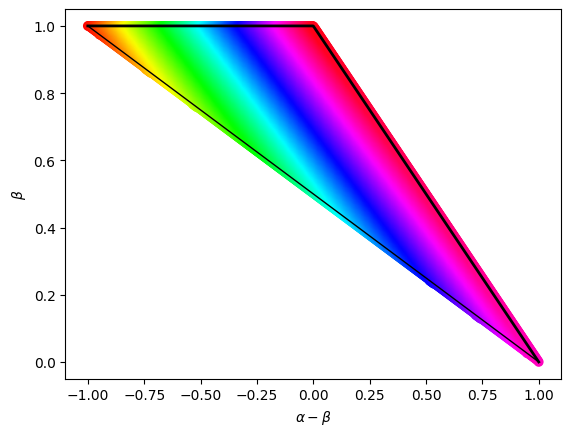

In [395]:
fig, ax = plt.subplots()

xs = []
ys = []
vs = []

N = 500
cmap = "hsv"

theta = 0.9
vs2 = []
for x in np.linspace(-1, 1, N):
    for y in np.linspace(0, 1, N):
        if x >= 1 - 2 * y:
            if x + y <= 1:
                v = x * theta + y - np.maximum(theta, 1-theta)
                vs.append(v)

                #beta = y
                #alpha = x + beta
                # pr1 = theta - alpha * theta + beta - theta * beta
                # ex = tau * (1 - 2 * prob_state0) * pr1
                #vs.append(ex)]

                vs2.append(x * theta + y )
                xs.append(x)
                ys.append(y)

ax.scatter(xs, ys, c=vs, cmap=cmap)
ax.set_xlabel(r"$\alpha - \beta$")
ax.set_ylabel(r"$\beta$")

xs = np.linspace(-1, 1, 1000)
boundary_top = np.ones(len(xs))
boundary_top[xs >= 0] = -xs[xs >= 0] + 1
ax.plot(xs, boundary_top, color="k", lw=2)
boundary_bottom_actual = 0.5 * (1 - xs)
ax.plot(xs, boundary_bottom_actual, c="k", lw=1)
# ax.fill_between(xs, boundary_top, boundary_bottom_actual, color="r", alpha=0.1)



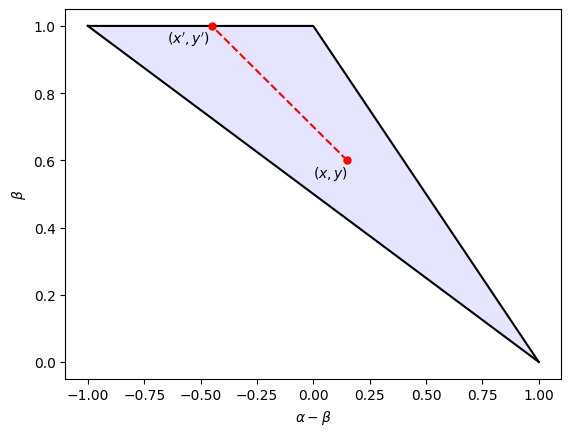

In [511]:
fig, ax = plt.subplots()

xs = np.linspace(-1, 1, 1000)


boundary_top = np.ones(len(xs))
boundary_top[xs >= 0] = -xs[xs >= 0] + 1
ax.plot(xs, boundary_top, color="k")
boundary_bottom_actual = 0.5 * (1 - xs)
ax.plot(xs, boundary_bottom_actual, c="k")
ax.fill_between(xs, boundary_top, boundary_bottom_actual, color="b", alpha=0.1)

ax.set_xlabel(r"$\alpha - \beta$")
ax.set_ylabel(r"$\beta$")
ax.text(0, 0.55, r"$(x, y)$", 
        fontsize = 10, color ="k") 
ax.text(-0.65, 0.95, r"$(x^\prime, y^\prime)$", 
        fontsize = 10, color ="k") 



ax.plot([0.15, -0.45], [0.6, 1], "--o", color="r", markersize=5)



(0.09999999999999998, 0.09999999999999998)

In [458]:
type = 0.8

ps0_x0 = 0.7
ps1_x0 = 0.3
ps1_x1 = 1
ps0_x1 = 0

ps0 = (ps0_x0 * type) + (ps0_x1 * (1-type))
ps1 = (ps1_x0 * type) + (ps1_x1 * (1-type))
px0_s0 = (ps0_x0 * type) / ps0
px0_s1 = (ps1_x0 * type) / ps1
print(px0_s0, ps0)
print(px0_s1, ps1)

1.0 0.5599999999999999
0.5454545454545455 0.43999999999999995


In [447]:
(0.3 * 0.6) / ((0.3 * 0.6) + (1 * 0.4))

0.31034482758620685

In [446]:
1-(0.7 * 0.6) + (0 * 0.4)

0.5800000000000001

In [460]:
from scipy import stats
pdf = stats.uniform(0, 1).pdf
cdf = stats.uniform(0, 1).cdf

def objective(q, theta, pdf, cdf, tau, prob_state0):
    return q * (theta * pdf(theta) + cdf(theta)) + np.minimum(-q, 0) * pdf(theta) - tau * prob_state0 - tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * q + (1 - 2 * prob_state0) * np.minimum(-q, 0))




In [508]:

tau = 1
prob_state0 = 1

Nq = 5
N = 1000
qs = np.linspace(-1, 1, Nq)
thetas = np.linspace(0, 1, N)

objectives = np.zeros((Nq, N))

for i, q in enumerate(qs):
    objectives[i, :] =  objective(q, thetas, pdf, cdf, tau, prob_state0)


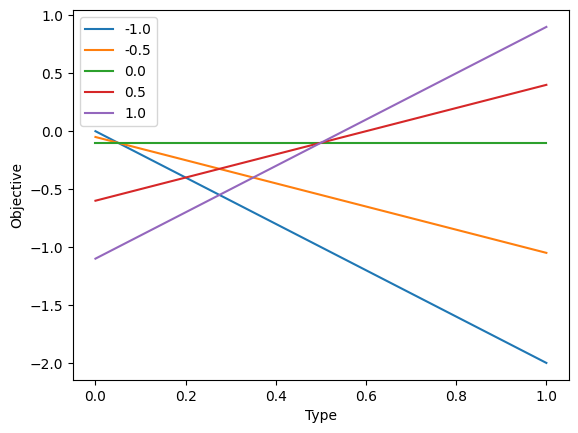

In [507]:
fig, ax = plt.subplots()
for i, q in enumerate(qs):
    ax.plot(thetas, objectives[i], label=q)

ax.set_xlabel("Type")
ax.set_ylabel("Objective")
ax.legend()


In [596]:
tau = 0.8
prob_state0 = 0.3
theta = 0.2

def calc_externality(x):
    alpha, beta = x[0], x[1]
    pr1 = theta - alpha * theta + beta - theta * beta
    #return tau * prob_state0 + tau * (1 - 2 * prob_state0) * pr1
    return tau * (1 - 2 * prob_state0) * pr1


def calc_value(x):
    alpha, beta = x[0], x[1]
    return (alpha - beta) * theta + beta - np.maximum(theta, 1-theta)
    #return beta - 1

def calc_neg_value(x):
    return -calc_value(x)

def calc_objective(x):
    return calc_externality(x)-calc_value(x)

Nq = 200
objectives = []

alphas = np.linspace(0, 1, Nq)
betas = np.linspace(0, 1, Nq)
externalities = []
values = []
qs = []
for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        if alpha + beta >= 1:

            q = [alpha, beta]
            externalities.append(calc_externality(q))
            values.append(calc_value(q))
            qs.append(alpha - beta)


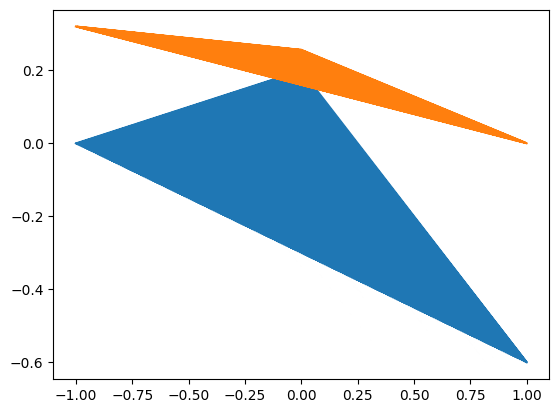

In [597]:
plt.plot(qs, values)
plt.plot(qs, externalities)

   

In [551]:
np.max(objectives)

1.0

In [642]:
def value(q, type):
    return -np.maximum(type, 1-type) + type * q + 1 + np.minimum(-q, 0)

tau = 1
prob_state0 = 1



def ext(q, prob_state0):
    return tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * q + (1 - 2 * prob_state0) * np.minimum(-q, 0))

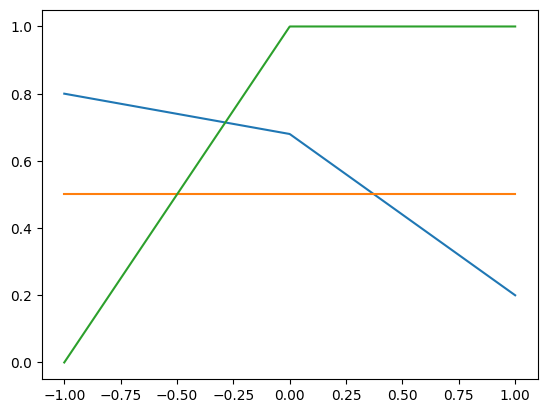

In [644]:
qs = np.linspace(-1, 1, 1000)
type = 1


tau = 1
plt.plot(qs, ext(qs, 0.2))
plt.plot(qs, ext(qs, 0.5))
plt.plot(qs, ext(qs, 1))

In [657]:
types = np.linspace(0.01, 0.99, 10)

informativeness = 0.5
state = 0

prob_signal0_state0 = 1 if informativeness > 0 else 1 + informativeness
prob_signal1_state1 = 1 if informativeness <= 0 else 1 - informativeness

prob_signal0_state1 = 1 - prob_signal1_state1
prob_signal1_state0 = 1 - prob_signal0_state0

prob_signal0 = prob_signal0_state0 * types + prob_signal0_state1 * (1 - types)
prob_signal1 = prob_signal1_state0 * types + prob_signal1_state1 * (1 - types)

prob_state0_signal0 = prob_signal0_state0 * types / prob_signal0
prob_state0_signal1 = prob_signal1_state0 * types / prob_signal1

signals = np.random.uniform(0, 1, size=(1000, len(types))) <= (
    prob_signal1_state1 if state == 1 else prob_signal1_state0
)

probs_state0 = signals * prob_state0_signal1 + (1 - signals) * prob_state0_signal0

probs_state0.mean(axis=0)


array([0.01980198, 0.21251241, 0.37104072, 0.50374065, 0.61644889,
       0.71336669, 0.79759519, 0.87147335, 0.93679858, 0.99497487])

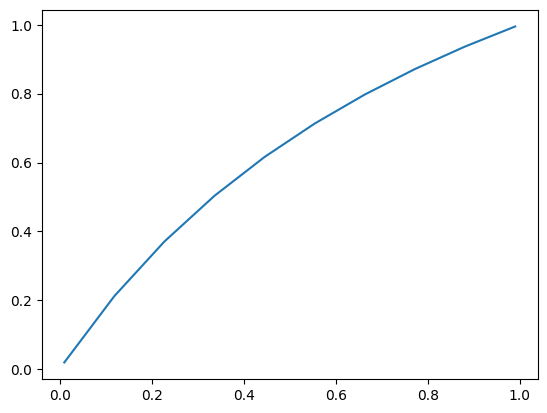

In [658]:
plt.plot(types, probs_state0.mean(axis=0))